In [ ]:
!pip install nltk scikit-learn matplotlib seaborn

In [ ]:
import nltk
nltk.download('punkt', force=True)
nltk.download('stopwords', force=True)
nltk.download('wordnet', force=True)
nltk.download('vader_lexicon', force=True)
nltk.download('averaged_perceptron_tagger', force=True)
nltk.download('punkt_tab', force=True)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [1]:
import json
import random
with open('positive_data.json', 'r') as f:
    positive_data = json.load(f)

with open('negative_data.json', 'r') as f:
    negative_data = json.load(f)

data = positive_data + negative_data
random.shuffle(data)

print(f"Total samples loaded: {len(data)}")

Total samples loaded: 196


In [2]:
import pandas as pd

df = pd.DataFrame(data)
print(df['label'].value_counts())

df.head()

label
positive    98
negative    98
Name: count, dtype: int64


,sentence,label
0,The colors and visuals were stunning.,positive
1,An amazing and delightful experience.,positive
2,It works better than I ever expected.,positive
3,I cannot recommend this to my friends.,negative
4,I dislike the disregard for sustainability.,negative


In [7]:
import nltk
nltk.download('stopwords')



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [9]:
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# 1. Download all required NLTK datasets first
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')

# 2. Initialize your NLTK objects
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


# 3. Define the preprocessing function
def preprocess_text(text):
    tokens = word_tokenize(text)
    filtered_tokens = [
        w.lower()
        for w in tokens
        if w.isalpha() and w.lower() not in stop_words
    ]

    lemmas = [lemmatizer.lemmatize(token) for token in filtered_tokens]
    return ' '.join(lemmas)


# 4. Apply to your DataFrame
df['processed_text'] = df['sentence'].apply(preprocess_text)
print(df[['sentence', 'processed_text']].head())


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


                                      sentence  \
0        The colors and visuals were stunning.   
1        An amazing and delightful experience.   
2        It works better than I ever expected.   
3       I cannot recommend this to my friends.   
4  I dislike the disregard for sustainability.   

                     processed_text  
0            color visuals stunning  
1     amazing delightful experience  
2         work better ever expected  
3                  recommend friend  
4  dislike disregard sustainability  


In [10]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['processed_text'])
y = df['label'].map({'positive': 1, 'negative': 0}).values

print(f"Feature matrix shape: {X.shape}")

Feature matrix shape: (196, 347)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Accuracy: 0.4
Classification Report:
               precision    recall  f1-score   support

           0       0.42      0.55      0.48        20
           1       0.36      0.25      0.29        20

    accuracy                           0.40        40
   macro avg       0.39      0.40      0.39        40
weighted avg       0.39      0.40      0.39        40

Confusion Matrix:
 [[11  9]
 [15  5]]


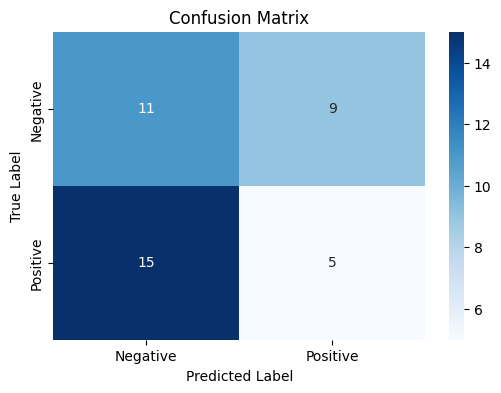

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[
            'Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [17]:
import pandas as pd
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# 1. Download the required lexicon asset
nltk.download('vader_lexicon')

# 2. Initialize the analyzer
sia = SentimentIntensityAnalyzer()


# 3. Define the sentiment logic function
def get_vader_sentiment(text):
    scores = sia.polarity_scores(text)
    compound = scores['compound']
    if compound >= 0.05:
        return 'positive'
    elif compound <= -0.05:
        return 'negative'
    else:
        return 'neutral'


# 4. Run the sample test
sample_text = "It is a worst product."
print(f"Sample test result: {get_vader_sentiment(sample_text)}")

# 5. Apply the function safely to your DataFrame
df['vader_sentiment'] = df['sentence'].apply(get_vader_sentiment)
print("\nDataFrame Preview:")
print(df[['sentence', 'vader_sentiment']].head())


Sample test result: negative

DataFrame Preview:
                                      sentence vader_sentiment
0        The colors and visuals were stunning.        positive
1        An amazing and delightful experience.        positive
2        It works better than I ever expected.        positive
3       I cannot recommend this to my friends.        positive
4  I dislike the disregard for sustainability.        negative


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [18]:
from sklearn.metrics import accuracy_score

df['vader_sentiment'] = df['sentence'].apply(get_vader_sentiment)

vader_labels = df['vader_sentiment'].map(
    {'positive': 1, 'negative': 0, 'neutral': -1})
valid_indices = vader_labels != -1

print("VADER Sentiment Accuracy compared to labels:")
print(accuracy_score(y[valid_indices], vader_labels[valid_indices]))

VADER Sentiment Accuracy compared to labels:
0.9548387096774194


In [19]:
def predict_sentiment(text):
    processed = preprocess_text(text)
    vectorized = vectorizer.transform([processed])
    pred = model.predict(vectorized)[0]
    return 'positive' if pred == 1 else 'negative'


test_sentences = [
    "This is an amazing product with great quality.",
    "I did not like the service at all, very poor."
]

for text in test_sentences:
    print(f"Sentence: {text} => Sentiment: {predict_sentiment(text)}")

Sentence: This is an amazing product with great quality. => Sentiment: positive
Sentence: I did not like the service at all, very poor. => Sentiment: negative


In [20]:
import joblib

joblib.dump(model, 'sentiment_nb_model.joblib')
joblib.dump(vectorizer, 'count_vectorizer.joblib')

['count_vectorizer.joblib']